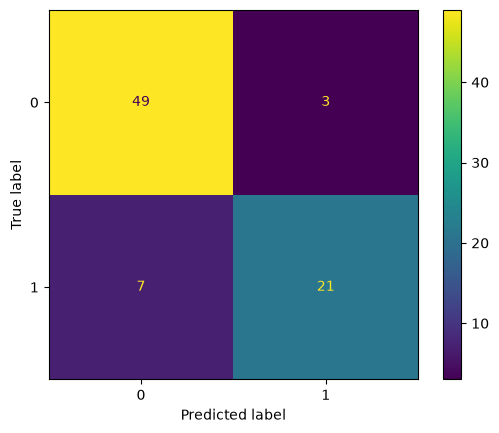

              precision    recall  f1-score   support

           0       0.88      0.94      0.91        52
           1       0.88      0.75      0.81        28

    accuracy                           0.88        80
   macro avg       0.88      0.85      0.86        80
weighted avg       0.88      0.88      0.87        80



In [ ]:
import pandas as jo

i = jo.read_csv('social_network_ads.csv')

r = jo.read_csv('social_network_ads.csv', usecols = ['Gender', 'Age', 'EstimatedSalary', 'Purchased'])
dummies = jo.get_dummies(r['Gender'], drop_first=True)
r = jo.concat([r, dummies], axis=1).drop('Gender', axis=1)
X = r.drop('Purchased', axis=1)
y = r['Purchased']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.fit_transform(X_test)

from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(scaled_X_train, y_train)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = log_model.predict(scaled_X_test)
confusion_matrix = confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

print(classification_report(y_test, y_pred))